# Example 17: Bootstrapping

Bootstrapping is a statistical resampling technique used to estimate the variability or uncertainty of a statistic or model by repeatedly drawing random samples with replacement from the original dataset. Like k-fold cross validation, this is a technique one could use to evaluate how well the modeling technique matches up with the dataset. 

In concise terms, bootstrapping works by creating multiple "bootstrap samples" by randomly selecting data points from the original dataset, with replacement. These samples are used to calculate statistics or metrics of interest, such as means, variances, or model performance, multiple times. By analyzing the distribution of these statistics across the bootstrap samples, you can estimate confidence intervals, standard errors, or assess the reliability of your results without requiring additional data. Bootstrapping is a powerful and versatile technique commonly used in statistical analysis and machine learning.

In [1]:
# Standard imports
import matplotlib.pyplot as plt
import numpy as np

# Dataset 
from sklearn.datasets import load_diabetes

# For computing bootstrapping for a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Just like k-fold cross validation, we will use the diabetes dataset and attempt to evaluate how well it is suited for a linear model. 

In [2]:
# Load the diabetes dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

In [3]:
# Create a linear regression model
model = LinearRegression()

# Lists to store bootstrapped scores
mse_scores = []
r2_scores = []

# Number of bootstrap iterations
num_rounds = 100

# Perform bootstrapping
for k in range(num_rounds):
    # Generate random indices with replacement
    indices = np.random.choice(len(X), len(X), replace=True)
    X_bootstrap, y_bootstrap = X[indices], y[indices]
    
    # Fit the model and make predictions
    model.fit(X_bootstrap, y_bootstrap)
    y_pred = model.predict(X_bootstrap)
    
    # Calculate mean squared error and R-squared
    mse = mean_squared_error(y_bootstrap, y_pred)
    r2 = r2_score(y_bootstrap, y_pred)
    
    mse_scores.append(mse)
    r2_scores.append(r2)

# Calculate bootstrapped mean and confidence intervals for MSE and R-squared
mse_mean = np.mean(mse_scores)
mse_std = np.std(mse_scores, ddof=1)
mse_ci = (mse_mean - 1.96 * mse_std / np.sqrt(num_rounds), mse_mean + 1.96 * mse_std / np.sqrt(num_rounds))

r2_mean = np.mean(r2_scores)
r2_std = np.std(r2_scores, ddof=1)
r2_ci = (r2_mean - 1.96 * r2_std / np.sqrt(num_rounds), r2_mean + 1.96 * r2_std / np.sqrt(num_rounds))

# Print the results
print("Bootstrapped Mean MSE:", mse_mean)
print("95% Confidence Interval for MSE:", mse_ci)

print("Bootstrapped Mean R-squared:", r2_mean)
print("95% Confidence Interval for R-squared:", r2_ci)

Bootstrapped Mean MSE: 2831.9869257127825
95% Confidence Interval for MSE: (2801.7036122081163, 2862.2702392174488)
Bootstrapped Mean R-squared: 0.5225548926851943
95% Confidence Interval for R-squared: (0.5173796846512824, 0.5277301007191062)


Typically, we perform bootstrapping with several samples, like 1000 or more. Here, however, we have opted to do fewer samples for the sake of visualizing what is happening with the samples we see. Below, we plot the the scores of each boostrapped sample as well as the overall average. 

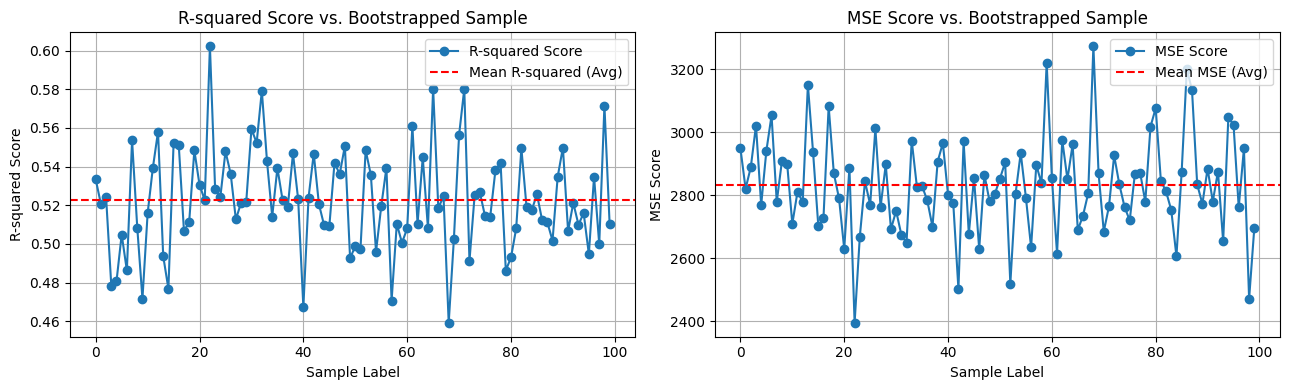

In [4]:
# Plot the mean R-squared scores versus the number of folds (k)
plt.figure(figsize=(13, 4))
plt.subplot(1, 2, 1)
plt.plot(list(range(num_rounds)), r2_scores, marker='o', linestyle='-', label='R-squared Score')
plt.axhline(y=np.mean(r2_mean), color='r', linestyle='--', label='Mean R-squared (Avg)')
plt.xlabel('Sample Label')
plt.ylabel('R-squared Score')
plt.title(f'R-squared Score vs. Bootstrapped Sample')
plt.grid(True)
plt.legend()

# Plot the mean MSE scores versus the number of folds (k)
plt.subplot(1, 2, 2)
plt.plot(list(range(num_rounds)), mse_scores, marker='o', linestyle='-', label='MSE Score')
plt.axhline(y=np.mean(mse_mean), color='r', linestyle='--', label='Mean MSE (Avg)')
plt.xlabel('Sample Label')
plt.ylabel('MSE Score')
plt.title(f'MSE Score vs. Bootstrapped Sample')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Similarly, the actual model we use is the model constructed from the full dataset, not any bootstrapped set. 

In [5]:
model = LinearRegression()
model.fit(X, y)

print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Model Coefficients: [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]
Model Intercept: 152.13348416289597
